In [1]:
pip install pandas numpy matplotlib seaborn

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.9 MB 23.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 24.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 22.6 MB/s  0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   -------------------- ------------------- 6.3/12.4 MB 29.8 MB/s eta 0:00:01
   ---------------------------------------  12.3/12.4 MB 31.1 MB/s eta 0:00:01
   ---------------------------------------- 12.4/12.4 MB 28.8 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------------------ --- 7.6/8.3 MB 40.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 32.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 33.6 MB/s  0:00:00
   ----------------------------------

In [4]:
pip install kagglehub


   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ----------------------------------------  0/10 [urllib3]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   ---- -----------------------------------  1/10 [tqdm]
   -------- -------------------------------  2/10 [pyyaml]
   -------- -------------------------------  2/10 [pyyaml]
   -------- -------------------------------  2/10 [pyyaml]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  3/10 [protobuf]
   ------------ ---------------------------  

In [5]:
import pandas as pd
import os
import kagglehub

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
# El archivo real está dentro de esa ruta y se llama 'credit_risk_dataset.csv'
ruta_original = os.path.join(path, "credit_risk_dataset.csv")

# 2. Definimos el nombre nuevo
new_name = "datos_credito_crudos.csv"

if os.path.exists(ruta_original):
    import shutil
    shutil.copy(ruta_original, new_name)
    print(f"✅ ¡Éxito! El archivo ha sido copiado a tu carpeta como: {new_name}")
else:
    print("❌ No se encontró el archivo original. Verifica la descarga de kagglehub.")


df = pd.read_csv(new_name)

# 5. Vista previa
df.head()

c:\Users\fedea\python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 368k/368k [00:00<00:00, 669kB/s]

Extracting files...
✅ ¡Éxito! El archivo ha sido copiado a tu carpeta como: datos_credito_crudos.csv


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [6]:
# 1. Ver qué columnas tienen nulos
print("--- Columnas con datos faltantes ---")
print(df.isnull().sum())

# 2. Ver estadísticas clave para detectar errores de "lógica"
print("\n--- Resumen estadístico (Edad y Empleo) ---")
print(df[['person_age', 'person_emp_length']].describe())

--- Columnas con datos faltantes ---
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

--- Resumen estadístico (Edad y Empleo) ---
         person_age  person_emp_length
count  32581.000000       31686.000000
mean      27.734600           4.789686
std        6.348078           4.142630
min       20.000000           0.000000
25%       23.000000           2.000000
50%       26.000000           4.000000
75%       30.000000           7.000000
max      144.000000         123.000000


In [7]:
# 1. Eliminar errores físicos de edad y empleo
df_clean = df[df['person_age'] < 90].copy()
df_clean = df_clean[df_clean['person_emp_length'] < 60] # Nadie trabaja +60 años en este dataset

# 2. Imputar nulos
# Para la tasa de interés, usamos la mediana
mediana_tasa = df_clean['loan_int_rate'].median()
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(mediana_tasa)

# Para empleo, usamos la mediana (o puedes usar 0)
mediana_emp = df_clean['person_emp_length'].median()
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(mediana_emp)

# 3. Verificación Final
print("--- Nulos después de la limpieza ---")
print(df_clean.isnull().sum())
print("\n--- Estadísticas después de la limpieza ---")
print(df_clean[['person_age', 'person_emp_length']].describe())

# 4. Guardar el dataset limpio para SQL
df_clean.to_csv("datos_credito_limpios.csv", index=False)

--- Nulos después de la limpieza ---
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

--- Estadísticas después de la limpieza ---
         person_age  person_emp_length
count  31678.000000       31678.000000
mean      27.728581           4.782183
std        6.202358           4.034956
min       20.000000           0.000000
25%       23.000000           2.000000
50%       26.000000           4.000000
75%       30.000000           7.000000
max       84.000000          41.000000


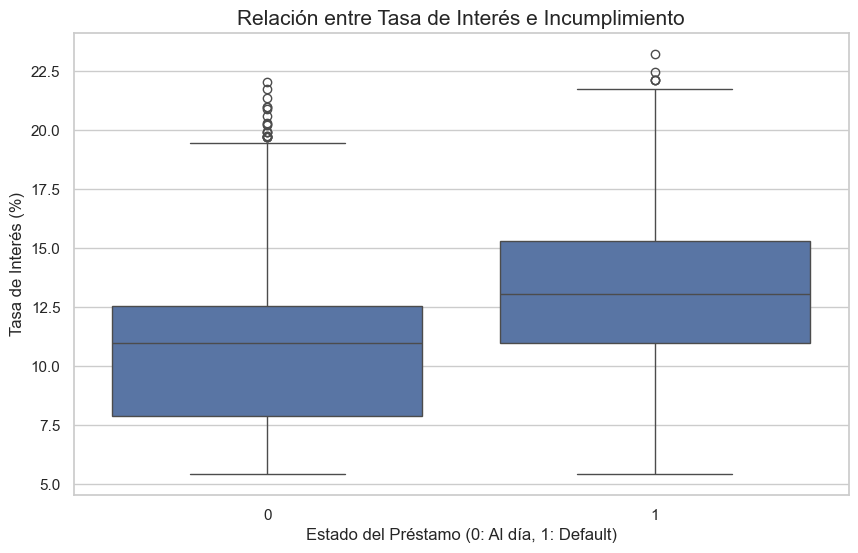

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configuramos el estilo visual
sns.set_theme(style="whitegrid")

# Creamos el gráfico
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_int_rate', data=df_clean)

# Personalización para que se vea profesional
plt.title('Relación entre Tasa de Interés e Incumplimiento', fontsize=15)
plt.xlabel('Estado del Préstamo (0: Al día, 1: Default)', fontsize=12)
plt.ylabel('Tasa de Interés (%)', fontsize=12)
plt.show()

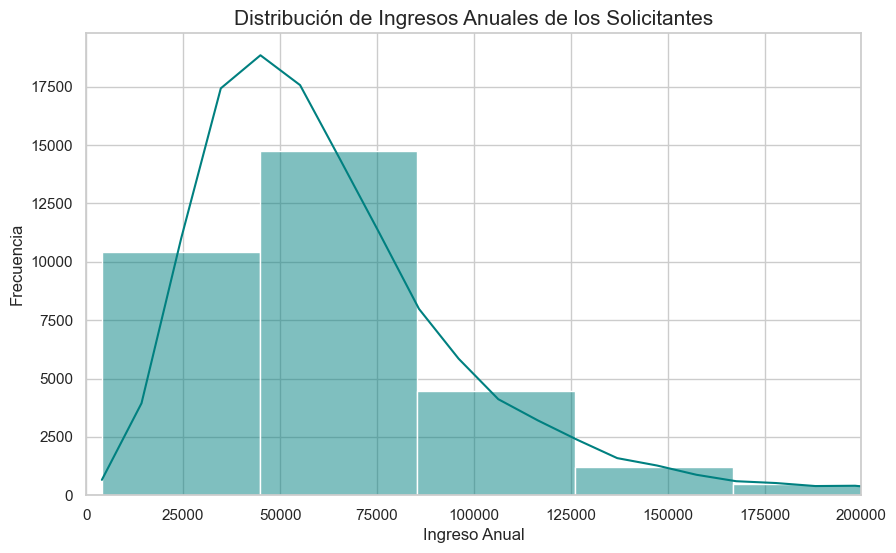

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['person_income'], bins=50, kde=True, color='teal')

# Limitamos el eje X para que los millonarios no "aplasten" el gráfico
plt.xlim(0, 200000) 

plt.title('Distribución de Ingresos Anuales de los Solicitantes', fontsize=15)
plt.xlabel('Ingreso Anual', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.show()

In [10]:
# 1. Renombrar columnas para que sean "SQL Friendly" (sin puntos ni espacios)
# Aunque este dataset ya está bastante limpio, es una buena práctica Senior
df_clean.columns = [col.replace('.', '_').lower() for col in df_clean.columns]

# 2. Verificar tipos de datos para SQL
# Es importante saber qué es INT y qué es FLOAT para crear la tabla en MySQL
print("--- Tipos de datos para MySQL ---")
print(df_clean.dtypes)

# 3. Exportar el CSV definitivo para importar en MySQL
df_clean.to_csv("credit_risk_for_sql.csv", index=False)
print("\n✅ Archivo 'credit_risk_for_sql.csv' creado y listo para MySQL.")

--- Tipos de datos para MySQL ---
person_age                      int64
person_income                   int64
person_home_ownership             str
person_emp_length             float64
loan_intent                       str
loan_grade                        str
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file         str
cb_person_cred_hist_length      int64
dtype: object

✅ Archivo 'credit_risk_for_sql.csv' creado y listo para MySQL.
